## 1.Base Line (mean prediction)
## 2.Data Cleaning & Preparation
## 3.Linear Regression Model
## 4.Feature Engg.
## 5.Tunning
## 6.Cross Validation
## 7.Residual Analysis

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
data = {
    'StudyHours': [2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Attendance': [60, 65, 70, 72, 75, 80, 85, 88, 90],
    'PrevScore': [40, 45, 50, 55, 60, 65, 70, 75, 80],
    'FinalMarks': [50, 55, 60, 65, 70, 75, 78, 85, 88]
}

In [3]:
df=pd.DataFrame(data)
df

,StudyHours,Attendance,PrevScore,FinalMarks
0,2,60,40,50
1,3,65,45,55
2,4,70,50,60
3,5,72,55,65
4,6,75,60,70
5,7,80,65,75
6,8,85,70,78
7,9,88,75,85
8,10,90,80,88


In [4]:
y = df['FinalMarks']
y

0    50
1    55
2    60
3    65
4    70
5    75
6    78
7    85
8    88
Name: FinalMarks, dtype: int64

In [5]:
y_pred_baseline=np.repeat(y.mean(),len(y))

In [6]:
mae = mean_absolute_error(y,y_pred_baseline)
print(mae)

10.716049382716049


In [7]:
mse = mean_squared_error(y,y_pred_baseline)
print(mse)

154.02469135802468


In [8]:
rmse = np.sqrt(mse)
print(rmse)

12.410668449282847


In [9]:
r2 = r2_score(y,y_pred_baseline)
print(f'Baseline MAE = {mae:.2f}, RMSE = {rmse:.2f}, R-Squared = {r2:.2f}')

Baseline MAE = 10.72, RMSE = 12.41, R-Squared = 0.00


In [10]:
#clean data
print(df.isnull().sum())

StudyHours    0
Attendance    0
PrevScore     0
FinalMarks    0
dtype: int64


In [11]:
#fill in null place
df = df.fillna(df.mean())

In [12]:
df

,StudyHours,Attendance,PrevScore,FinalMarks
0,2,60,40,50
1,3,65,45,55
2,4,70,50,60
3,5,72,55,65
4,6,75,60,70
5,7,80,65,75
6,8,85,70,78
7,9,88,75,85
8,10,90,80,88


In [13]:
#data prep,find input ,output
X = df[['StudyHours','Attendance','PrevScore']]
y = df['FinalMarks']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,random_state = 42)

In [14]:
#Create model
model = LinearRegression()

In [15]:
model.fit(X_train,y_train)

LinearRegression()

In [16]:
y_pred = model.predict(X_test)
print(y_pred)

[83.23783784 55.16756757 73.92972973]


In [17]:
mae = mean_absolute_error(y_test,y_pred)
print(mae)

0.9999999999999906


In [18]:
mse = mean_squared_error(y_test,y_pred)
print(mse)

1.4262576089602934


In [19]:
rmse = np.sqrt(mse)
print(rmse)

1.19426027689122


In [20]:
r2 = r2_score(y_test,y_pred)
print(r2)

0.9908312010852552


In [21]:
# Combine both into a DataFrame <-- addition jer ni
y_all_prediction = model.predict(X)
comparison = pd.DataFrame({
    'Original Final Marks': y.values.flatten(),
    'Predicted Final Marks': y_all_prediction
})
 
# Display neatly
print("\nComparison of Original vs Predicted Marks:")
display(comparison)


Comparison of Original vs Predicted Marks:


,Original Final Marks,Predicted Final Marks
0,50,50.659459
1,55,55.167568
2,60,59.675676
3,65,64.621622
4,70,69.421622
5,75,73.929730
6,78,78.437838
7,85,83.237838
8,88,88.183784


### Exercise 2(Day-19)


ValueError: x and y must be the same size

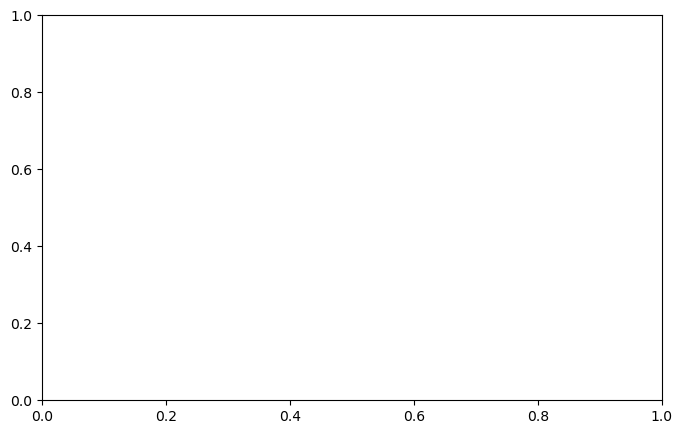

In [22]:
plt.figure(figsize=(8,5))
plt.scatter(X_train,y_train, color = 'darkblue', label = 'Actual Salary', s=100)
plt.plot(X_train, y_pred, color = 'darkred', linewidth = 2, label = 'Predicted Salary')
for i in range(len(X_train)):
    plt.plot([X_train.iloc[i,0], X_train.iloc[i,0]],[y_train.iloc[i],y_pred[i]], color = 'yellow', linestyle='--', linewidth = 2)
plt.title('Actual Salary Vs Predicted Salary')
plt.xlabel('Experience in Year')
plt.ylabel('Salary of Person')
plt.legend()
plt.grid(color = 'grey', linestyle ='--')
plt.show()

In [ ]:
dat={
    'Area':[850,900,1000,1100,1200,1500,1600,1800,2000],
    'Bedrooms':[1,2,2,2,3,3,2,4,4],
    'Age':[1,2,3,2,1,2,2,1,2],
    'Price':[5,6,7,7,7,9,9,11,None],}

In [ ]:
datf=pd.DataFrame(dat)
datf

In [ ]:
print(datf.isnull().sum())

In [ ]:
datf = datf.fillna(datf.mean())
datf

In [ ]:
y = datf['Price']
y

In [ ]:
y_pred_baseline=np.repeat(y.mean(),len(y))

In [ ]:
mae = mean_absolute_error(y,y_pred_baseline)
print(mae)

In [ ]:
mse = mean_squared_error(y,y_pred_baseline)
print(mse)

In [ ]:
mse = mean_squared_error(y_test,y_pred)
print(mse)

In [ ]:
rmse = np.sqrt(mse)
print(rmse)

In [ ]:
r2 = r2_score(y,y_pred_baseline)
print(f'Baseline MAE = {mae:.2f}, RMSE = {rmse:.2f}, R-Squared = {r2:.2f}')

In [ ]:
X = datf[['Area','Bedrooms','Age']]
y = datf['Price']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.5,random_state = 42)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train,y_train)

In [ ]:
y_pred = model.predict(X_test)
print(y_pred)

In [ ]:
mae = mean_absolute_error(y_test,y_pred)
print(mae)

In [ ]:
mse = mean_squared_error(y_test,y_pred)
print(mse)

In [ ]:
rmse = np.sqrt(mse)
print(rmse)